<a href="https://colab.research.google.com/github/brightmain/Setup-Project/blob/main/regresi_berganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [ ]:
data = {
    'jam_belajar': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    'jumlah_tugas': [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8],
    'nilai_sebelumnya': [65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92, 93, 95, 96],
    'kehadiran': [50, 55, 60, 65, 70, 75, 80, 85, 88, 90, 92, 94, 95, 96, 98],
    'nilai_akhir': [58, 62, 67, 72, 76, 81, 85, 88, 91, 94, 96, 98, 99, 100, 100]
}

df = pd.DataFrame(data)
print("=" * 60)
print("DATA REGRESI LINEAR BERGANDA")
print("=" * 60)
print(df)
print("\n")

DATA REGRESI LINEAR BERGANDA
    jam_belajar  jumlah_tugas  nilai_sebelumnya  kehadiran  nilai_akhir
0             2             1                65         50           58
1             3             2                68         55           62
2             4             2                70         60           67
3             5             3                72         65           72
4             6             3                75         70           76
5             7             4                78         75           81
6             8             4                80         80           85
7             9             5                82         85           88
8            10             5                85         88           91
9            11             6                88         90           94
10           12             6                90         92           96
11           13             7                92         94           98
12           14             7      

In [ ]:
X = df[['jam_belajar', 'jumlah_tugas', 'nilai_sebelumnya', 'kehadiran']]
y = df['nilai_akhir']

print("Variabel Independen (X):")
print("- Jam Belajar (jam/minggu)")
print("- Jumlah Tugas (per semester)")
print("- Nilai Ujian Sebelumnya")
print("- Kehadiran (%)")
print("\nVariabel Dependen (Y):")
print("- Nilai Akhir")
print("\n")

Variabel Independen (X):
- Jam Belajar (jam/minggu)
- Jumlah Tugas (per semester)
- Nilai Ujian Sebelumnya
- Kehadiran (%)

Variabel Dependen (Y):
- Nilai Akhir




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data Training: {len(X_train)} sampel")
print(f"Data Testing: {len(X_test)} sampel")
print("\n")


Data Training: 12 sampel
Data Testing: 3 sampel




In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
print("=" * 60)
print("HASIL REGRESI LINEAR BERGANDA")
print("=" * 60)
print(f"Intercept (konstanta): {model.intercept_:.2f}")
print("\nKoefisien Regresi:")
features = X.columns
for i, feature in enumerate(features):
    print(f"  {feature:15} : {model.coef_[i]:.4f}")

print("\nPersamaan Regresi:")
print(f"Nilai Akhir = {model.intercept_:.2f}", end="")
for i, feature in enumerate(features):
    sign = " + " if model.coef_[i] >= 0 else " - "
    print(f"{sign}{abs(model.coef_[i]):.4f} × {feature}", end="")
print("\n\n")

HASIL REGRESI LINEAR BERGANDA
Intercept (konstanta): -19.88

Koefisien Regresi:
  jam_belajar     : -1.1011
  jumlah_tugas    : 0.2781
  nilai_sebelumnya : 0.6643
  kehadiran       : 0.7363

Persamaan Regresi:
Nilai Akhir = -19.88 - 1.1011 × jam_belajar + 0.2781 × jumlah_tugas + 0.6643 × nilai_sebelumnya + 0.7363 × kehadiran




In [ ]:
y_pred = model.predict(X_test)

print("=" * 60)
print("PERBANDINGAN HASIL PREDIKSI vs AKTUAL")
print("=" * 60)
print(f"{'No':<4} {'Jam':<6} {'Tgs':<6} {'Nilai Sebelum':<14} {'Kehadiran':<10} {'Aktual':<8} {'Prediksi':<10} {'Error':<10}")
print("-" * 75)
for i in range(len(X_test)):
    error = y_test.iloc[i] - y_pred[i]
    print(f"{i+1:<4} {X_test.iloc[i,0]:<6} {X_test.iloc[i,1]:<6} {X_test.iloc[i,2]:<14} {X_test.iloc[i,3]:<10} {y_test.iloc[i]:<8} {y_pred[i]:<10.2f} {abs(error):<10.2f}")
print("\n")

PERBANDINGAN HASIL PREDIKSI vs AKTUAL
No   Jam    Tgs    Nilai Sebelum  Kehadiran  Aktual   Prediksi   Error     
---------------------------------------------------------------------------
1    11     6      88             90         94       94.40      0.40      
2    13     7      92             94         98       98.08      0.08      
3    2      1      65             50         58       58.19      0.19      




In [ ]:
print("=" * 60)
print("EVALUASI MODEL")
print("=" * 60)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"MSE  (Mean Squared Error)   : {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R² Score                    : {r2:.4f}")
print(f"Accuracy Model              : {r2*100:.2f}%")
print("\n")

EVALUASI MODEL
MAE  (Mean Absolute Error)  : 0.2196
MSE  (Mean Squared Error)   : 0.0660
RMSE (Root Mean Squared Error): 0.2570
R² Score                    : 0.9998
Accuracy Model              : 99.98%




In [ ]:
print("=" * 60)
print("PREDIKSI DATA MAHASISWA BARU")
print("=" * 60)
data_baru = pd.DataFrame([
    [10, 5, 85, 90],   # Mahasiswa 1
    [15, 8, 92, 95],   # Mahasiswa 2
    [5, 2, 70, 65]     # Mahasiswa 3
], columns=['jam_belajar', 'jumlah_tugas', 'nilai_sebelumnya', 'kehadiran'])

prediksi_baru = model.predict(data_baru)

for i in range(len(data_baru)):
    print(f"\nMahasiswa {i+1}:")
    print(f"  - Jam Belajar: {data_baru.iloc[i,0]} jam/minggu")
    print(f"  - Jumlah Tugas: {data_baru.iloc[i,1]} tugas")
    print(f"  - Nilai Sebelumnya: {data_baru.iloc[i,2]}")
    print(f"  - Kehadiran: {data_baru.iloc[i,3]}%")
    print(f"  → Prediksi Nilai Akhir: {prediksi_baru[i]:.2f}")
print("\n")

PREDIKSI DATA MAHASISWA BARU

Mahasiswa 1:
  - Jam Belajar: 10 jam/minggu
  - Jumlah Tugas: 5 tugas
  - Nilai Sebelumnya: 85
  - Kehadiran: 90%
  → Prediksi Nilai Akhir: 93.23

Mahasiswa 2:
  - Jam Belajar: 15 jam/minggu
  - Jumlah Tugas: 8 tugas
  - Nilai Sebelumnya: 92
  - Kehadiran: 95%
  → Prediksi Nilai Akhir: 96.89

Mahasiswa 3:
  - Jam Belajar: 5 jam/minggu
  - Jumlah Tugas: 2 tugas
  - Nilai Sebelumnya: 70
  - Kehadiran: 65%
  → Prediksi Nilai Akhir: 69.53




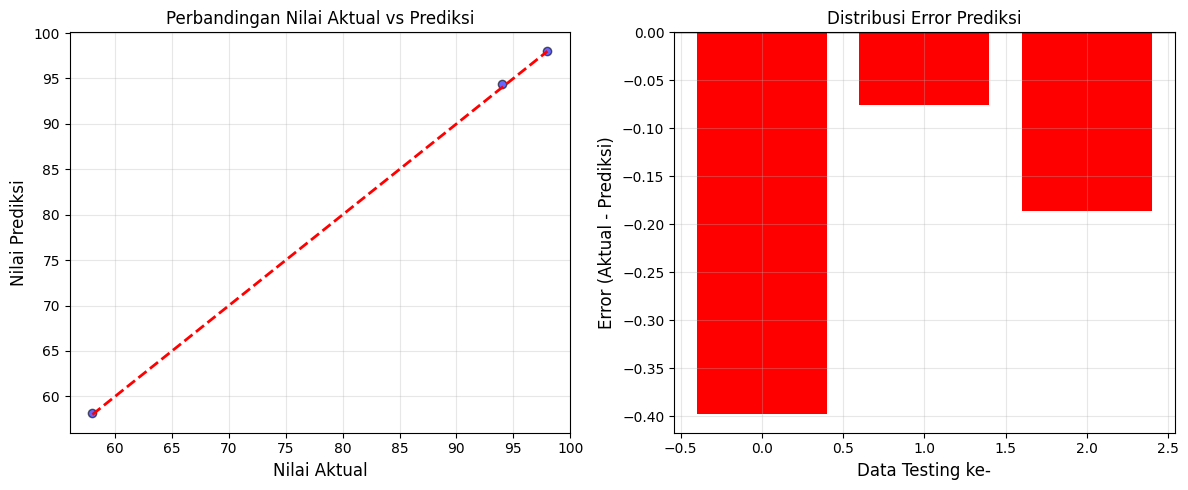

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Nilai Aktual", fontsize=12)
plt.ylabel("Nilai Prediksi", fontsize=12)
plt.title("Perbandingan Nilai Aktual vs Prediksi", fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
errors = y_test.values - y_pred
plt.bar(range(len(errors)), errors, color=['green' if e >= 0 else 'red' for e in errors])
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel("Data Testing ke-", fontsize=12)
plt.ylabel("Error (Aktual - Prediksi)", fontsize=12)
plt.title("Distribusi Error Prediksi", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()